<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

## Análisis y procesamiento de señales
# TS0: Primeros pasos en la simulación
### Gonzalo Constenla
[nbviewer](https://nbviewer.org/github/GConstenlaP/AyPS/blob/main/TS0/TS0%20Gconstenla.ipynb)

[Ver notebook en GitHub](https://github.com/GConstenlaP/AyPS/blob/main/TS0/TS0%20Gconstenla.ipynb)

##### En este trabajo se programó la generacion de una señal sinusoidal mediante una funcion en python y se definieron parametros para analizar su comportamiento al variar las frecuencias.

#### Codigo utilizado:
Importacion de Librerias requeridas,
definicion de *Fs*, frecuencia de muestreo (en hz) y *N*, Numero de muestras (Adimensional)

Y definicion de la funcion generadora de la señal
Usando:
\begin{equation}
x(t) = d_c + v_{\max}\sin\left(2\pi f\,t + \phi\right)
\end{equation}


In [4]:
import matplotlib.pyplot as plt
import numpy as np

fs = 1000 #hz
N = 1000 #muestras

def mi_funcion_sen(vmax, dc, ff, ph, nn=N, fs=fs):
    
    tt = np.arange(nn) / fs    
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx


#### Parametros:
* *tt*: tiempo de muestras (en segundos).

* *xx*: valores de señal (en voltios)

* *vmax*: amplitud (en voltios)

* *dc(direct current)*: valor medio de la señal (en voltios)

* *ff*: frecuencia de la señal (en hertz)

* *ph*: fase (en rad)

* *nn*: numero de muestras, adimensional

* *fs*: frecuencia de muestras (en hertz)

#### Script y su gráfica con parametros base (Frecuencia = 1)

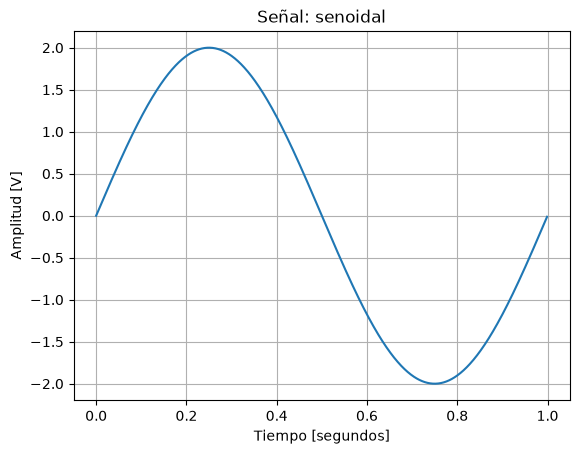

In [10]:

t, x = mi_funcion_sen(vmax=2, dc=0, ff=1, ph=0, nn=N, fs=fs)

plt.plot(t, x)
plt.title('Señal: senoidal' )
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.show()


El grafico cubre un ciclo de una senoidal con periodo de 1 segundo. (T= 1/ff, con ff=1)

Ts=1/fs, periodo de muestreo o tiempo entre muestras (en segundos). entonces con fs=1000 (muestras por segundo) y N = 1000 muestras, el tiempo que cubre la totalidad de las muestras es apróx. 1 segundo (exactamente: 0,999ms).


#### Scripts y sus Gráficas con ff = 10, 500, 999, 1001 y 2001

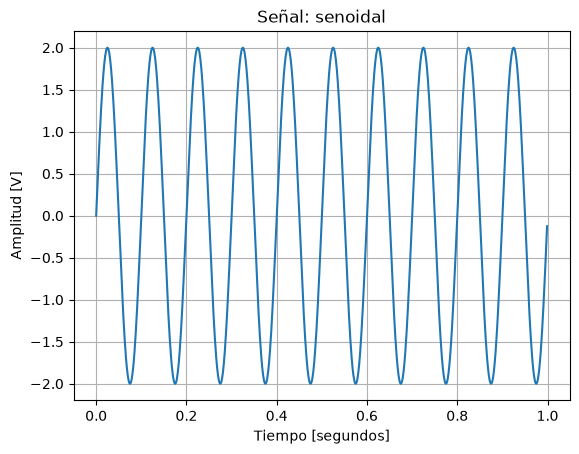

In [11]:
t, x = mi_funcion_sen(vmax=2, dc=0, ff=10, ph=0, nn=N, fs=fs)

plt.plot(t, x)
plt.title('Señal: senoidal' )
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.show()


En esta gráfica se ve que al subir la frecuencia hasta 10, se veran 10 ciclos dentro de un segundo.

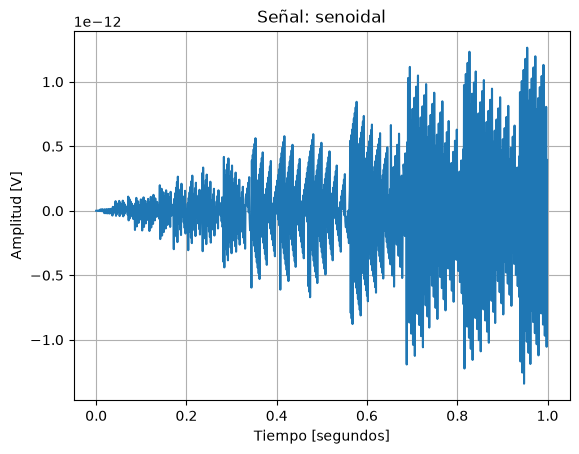

In [5]:
t, x = mi_funcion_sen(vmax=2, dc=0, ff=500, ph=0, nn=N, fs=fs)

plt.plot(t, x)
plt.title('Señal: senoidal' )
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.show()

Con frecuencia = 500 hz, gráficamente se observa un fenomeno que no es una representacion fisica de la onda, ya que según la formula de la funcion generadora, la señal deberia de tomar valor igual a 0 en todas las muestras, en las cuales la senoidal toca el eje.
    Y el gráfico es resultado de error de calculo computacional relacionado con los numeros de maquina (se puede observar en la leyenda del gráfico que el orden de la amplitud es muy chico y no se condice con la amplitud impuesta).

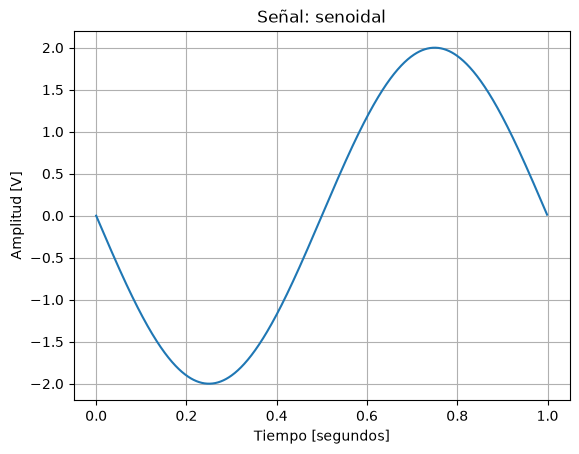

In [6]:
t, x = mi_funcion_sen(vmax=2, dc=0, ff=999, ph=0, nn=N, fs=fs)

plt.plot(t, x)
plt.title('Señal: senoidal' )
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.show()

En esta gráfica se ve un único ciclo (y con gráfica invertida) a pesar de tener input de ff = 999hz.

Fs, la frecuencia de muestreo es de 1000hz, constante en todas las gráficas. Por lo que La frecuancia de Nyquist, Fn = fs/2 = 500hz


El periodo de Muestreo Ts = 1/Fs = 1/1000 = 0,001s, este es el tiempo entre las muestras. ¿Y que ocurre con la señal luego de cada periodo?

Una señal de 999 hz (ff = 900), transita 999 ciclos por segundo y en 0,001 segundos transita 0,999 ciclos (999 * 0,001). Es decir que la señal transitó casi 1 ciclo en 0,001 segundos, por lo que para la proxima muestra, (al pasar tiempo = 1Ts) en el espectro de la señal apenas se vera variacion, y la suma de todas estas variaciones luego de todas las muestras con sus respectivos Ts, dibujan la gráfica de una unica señal (que equivale a la diferencia entre Fs y ff = 1hz y por eso tiene grafica de señal de 1hz).

¿Y por que esta invertida? La clave está en que la señal transitó casi 1 ciclo en 0,001 segundos (1Ts), porque para cuando transcurre cada periodo Ts, casi se completa un ciclo, y así se forma la imagen en sentido invertido, como si la señal corriera en valores de amplitud "marcha atrás".

Este fenomeno se observa para cualquier frecuencia ff = (Fs*K) - 1, k entero positivo. 


[Otros ejemplos](https://es.wikipedia.org/wiki/Aliasing#:~:text=editar-,Aliasing%20en%20fen%C3%B3menos%20peri%C3%B3dicos,luz%20de%20la%20televisi%C3%B3n%2C%20o%20con%20otra%20fuente%20de%20luz%2C%20etc.,-Muestreo%20de%20una)


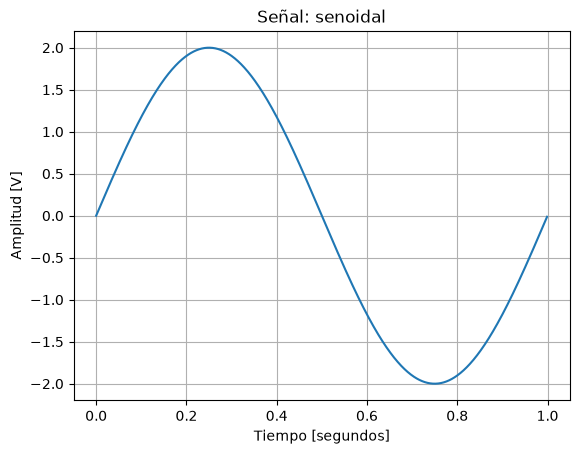

In [7]:
t, x = mi_funcion_sen(vmax=2, dc=0, ff=1001, ph=0, nn=N, fs=fs)

plt.plot(t, x)
plt.title('Señal: senoidal' )
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.show()

Luego de la explicación de la gráfica de ff=999. La deducción del resultado de ff = 1001 es natural: Mismo periodo de muestreo, pero ahora la señal transita 1,001 ciclos cada 0,001 segundos (1Ts). De nuevo casi un ciclo, pero ahora un poquito más, entonces se forma una gráfica que equivale al transcurso de un ciclo luego de todas las muestras, esta vez en sentido normal.

Y de forma analoga, este fenomeno se observa para cualquier frecuencia ff = (Fs*K) + 1, k entero positivo. Lo cual explica la gráfica siguiente también.


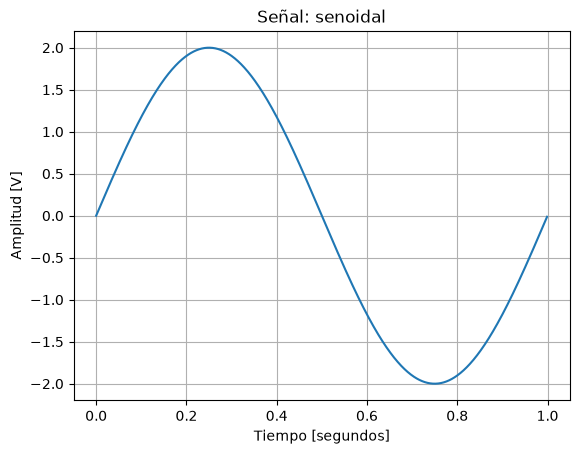

In [8]:
t, x = mi_funcion_sen(vmax=2, dc=0, ff=2001, ph=0, nn=N, fs=fs)

plt.plot(t, x)
plt.title('Señal: senoidal' )
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.grid()
plt.show()

#### Aliasing
El aliasing o solapamiento espectral por el muestro, es el efecto que explica por que al muestrear una señal, distintas frecuencias de la señal pueden producir exactamente la misma secuencia de muestras. Es decir, se pueden observar señales "alias" de una señal original, pero con frecuencias distintas.


Este fenomeno es consecuencia de frecuencias de señal superiores a la frecuencia de muestreo, por lo que para evitar este fenómeno se debe cumplir el criterio de Nyquist:
Fs > 2Fmax